In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

import warnings

In [2]:
# 경고 메시지 출력을 필터
warnings.filterwarnings('ignore')

In [3]:
body = pd.read_csv('../data/bodyPerformance.csv')
body.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [4]:
body.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


- age
    - 나이
- gender
    - 성별 ( 문자열 데이터 )
- height_cm
    - 키
- weight_kg
    - 무게
- body fat_%
    - 체지방률
- diastolic
    - 이완기 혈압
- systolic
    - 수축기 혈압
- gripForce
    - 악력
- sit and bend forward_cm
    - 앉아서 윗몸 앞으로 굽히기
- sit-ups counts
    - 윗몸 일으키기
- broad jump_cm
    - 제자리 멀리뛰기

In [5]:
body.describe()

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


In [6]:
# gender 컬럼 문자들을 숫자형태로 변환
body['gender'].unique()

array(['M', 'F'], dtype=object)

In [7]:
body['gender'].value_counts()

gender
M    8467
F    4926
Name: count, dtype: int64

In [8]:
# map 함수 활용
body['gender'].map(
    lambda x : 0 if x == 'M' else 1
)

0        0
1        0
2        0
3        0
4        0
        ..
13388    0
13389    0
13390    0
13391    1
13392    0
Name: gender, Length: 13393, dtype: int64

In [9]:
body['gender'].map(
    {
        'M' : 0,
        'F' : 1
    }
)

0        0
1        0
2        0
3        0
4        0
        ..
13388    0
13389    0
13390    0
13391    1
13392    0
Name: gender, Length: 13393, dtype: int64

In [11]:
# replace() 함수를 활용
body['gender'].replace('M', 0).replace('F',1)

0        0
1        0
2        0
3        0
4        0
        ..
13388    0
13389    0
13390    0
13391    1
13392    0
Name: gender, Length: 13393, dtype: int64

In [16]:
df = pd.get_dummies(body, columns=['gender'], drop_first = True)

In [18]:
# numpy를 활용하는 방법
np.where(
    body['gender'] == 'M', 0, 1
)

array([0, 0, 0, ..., 0, 1, 0])

In [19]:
# 분류 모델을 사용할때 target의 데이터들을 숫자형태로 변환
df['class'].value_counts()

class
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64

In [20]:
# class에서 A는 1 그 외의 값들은 0으로 변환
df['class_1'] = np.where(
    df['class'] == 'A',1,0
)

In [21]:
df['class_1'].value_counts()

class_1
0    10045
1     3348
Name: count, dtype: int64

In [22]:
flag = df['sit and bend forward_cm'] > 35
df.loc[flag,]

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,gender_M,class_1
2657,33.0,165.6,60.40,17.8,81.0,127.0,38.6,213.0,53.0,244.0,B,True,0
3355,45.0,164.4,64.40,24.3,96.0,142.0,38.5,185.0,44.0,223.0,A,True,1
3718,24.0,170.1,72.68,21.2,78.0,130.0,39.9,35.2,43.0,295.0,C,True,0
4203,46.0,164.4,63.60,23.4,70.0,115.0,36.0,42.0,42.0,210.0,A,True,1
4438,59.0,175.4,68.10,21.3,74.0,122.0,36.2,40.0,40.0,174.0,B,True,0
6161,51.0,162.2,58.20,25.1,79.0,131.0,27.2,35.2,25.0,134.0,D,False,0
6306,22.0,160.5,50.80,17.0,57.0,107.0,30.2,35.2,46.0,181.0,A,False,1
7797,24.0,168.3,61.30,24.5,72.0,110.0,30.1,35.2,39.0,182.0,C,False,0
8905,52.0,166.3,74.30,26.0,79.0,131.0,47.1,40.0,40.0,194.0,B,True,0
11794,41.0,166.5,56.50,27.2,82.0,135.0,25.7,35.2,32.0,174.0,A,False,1


In [25]:
# 독립 변수 종속 변수 데이터를 분할
x = df.drop(['class' , 'class_1'],axis = 1)
y = df['class_1']

In [26]:
# train , test 셋으로 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state=42, stratify = y
)

In [27]:
# 모델 생성
logR = LogisticRegression()

In [28]:
logR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
# 예측 확률 데이터를 확인
proba = pd.DataFrame(
    logR.predict_proba(X_train)
)

# 클래스별 점수 ( 분류의 대한 확신의 점수 )
cs = pd.DataFrame(
    logR.decision_function(X_train)
)

# proba, cs 데이터프레임을 단순 열 결합
df2 = pd.concat( [proba, cs], axis = 1 )

df2

,0,1,0
0,0.870468,0.129532,-1.905103
1,0.434912,0.565088,0.261838
2,0.998455,0.001545,-6.471298
3,0.965405,0.034595,-3.328832
4,0.638697,0.361303,-0.569714
...,...,...,...
9370,0.194887,0.805113,1.418562
9371,0.999984,0.000016,-11.056804
9372,0.929900,0.070100,-2.585156
9373,0.993188,0.006812,-4.982267


In [30]:
df2.columns = ['Not A', 'A', 'decision_function']
df2

,Not A,A,decision_function
0,0.870468,0.129532,-1.905103
1,0.434912,0.565088,0.261838
2,0.998455,0.001545,-6.471298
3,0.965405,0.034595,-3.328832
4,0.638697,0.361303,-0.569714
...,...,...,...
9370,0.194887,0.805113,1.418562
9371,0.999984,0.000016,-11.056804
9372,0.929900,0.070100,-2.585156
9373,0.993188,0.006812,-4.982267


In [31]:
df2.sort_values('decision_function', inplace = True)
df2.reset_index(drop = True, inplace = True)
df2

,Not A,A,decision_function
0,1.000000e+00,1.740546e-09,-20.169067
1,1.000000e+00,7.353003e-09,-18.728157
2,1.000000e+00,1.737694e-08,-17.868122
3,1.000000e+00,2.367212e-08,-17.558968
4,1.000000e+00,2.372304e-08,-17.556819
...,...,...,...
9370,1.768457e-03,9.982315e-01,6.335878
9371,1.547570e-03,9.984524e-01,6.469521
9372,1.127494e-03,9.988725e-01,6.786630
9373,1.332268e-15,1.000000e+00,34.263071


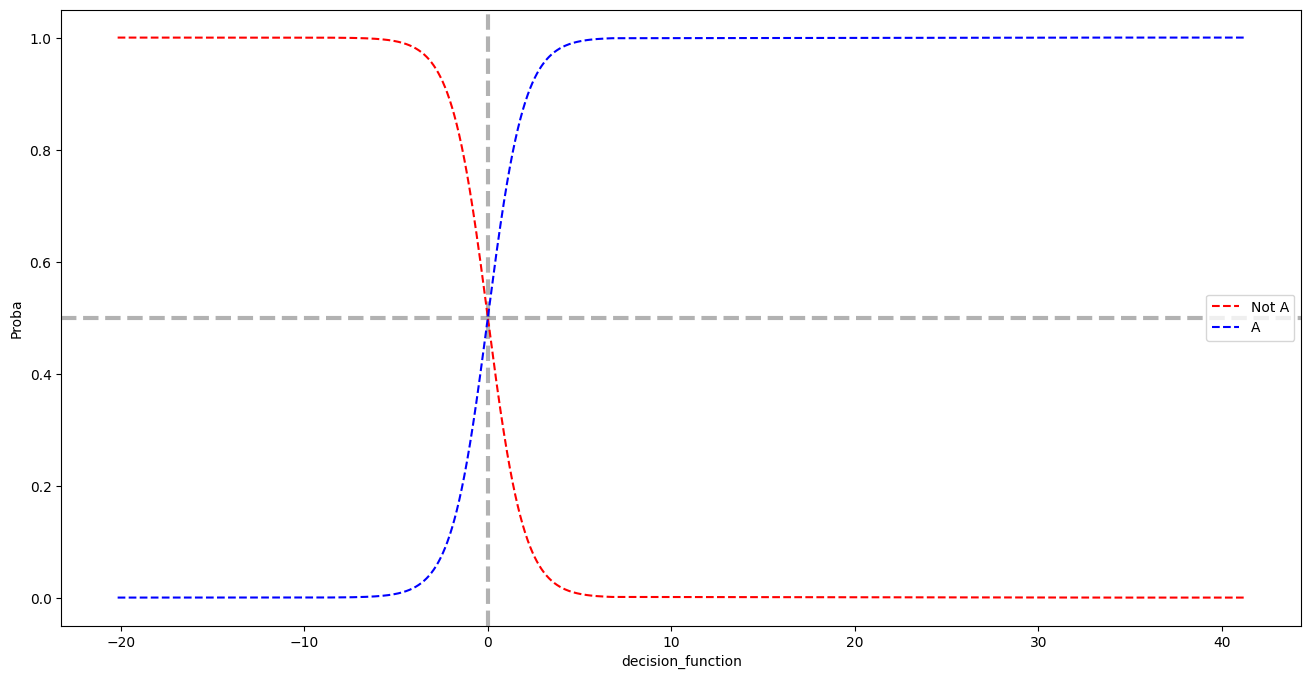

In [34]:
# 그래프 시각화
plt.figure(figsize = (16, 8))

# 보조선 추가
plt.axhline(y = 0.5, linestyle = '--', color = 'black', linewidth = 3, alpha = 0.3)
plt.axvline(x = 0, linestyle = '--', color = 'black', linewidth = 3, alpha = 0.3)

plt.plot(df2['decision_function'], df2['Not A'], 'r--', label = 'Not A')
plt.plot(df2['decision_function'], df2['A'], 'b--', label = 'A')

plt.legend()
plt.xlabel('decision_function')
plt.ylabel('Proba')

plt.show()

- 혼동행렬
    - 이진 분류의 예측 오류가 얼마인가 어떠한 유형의 오류가 발생하는지를 나타내는 지표
        - TN : 예측이 Negative(0), 실제 값 Negative(0)
        - FP : 예측이 Positive(1), 실제 값 Negative(0)
        - FN : 예측이 Negative(0), 실제 값 Positive(1)
        - TP : 예측이 Positive(1), 실제 값 Positive(1)
- 정확도
    - 실제 데이터와 예측 데이터가 얼마나 같은가?
    - TN + TP / TN + FP + FN + TP
- 정밀도
    - 양성 예측도
    - TP / TP + FP
    - 스팸 메일인지 아닌지 판단
- 재현율
    - TP / TP + FN
    - 암 환자 진단, 신용카드 사기 탐지
- F1_Score
    - 정밀도와 재현율을 결합한 분류 성능 지표
    - 어느 한쪽에 치우치지 않고 적절하게 조화를 이루었을 때 높은 수치를 나타냄
    - (2*TP) / (2*TP + FP + FN)

In [35]:
# 학습된 모델을 이용하여 예측
pred = logR.predict(X_test)

In [36]:
cm = confusion_matrix(y_test, pred)
acc = accuracy_score(y_test, pred)
prc = precision_score(y_test, pred)
rcll = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

In [37]:
print(cm)

[[2758  256]
 [ 394  610]]


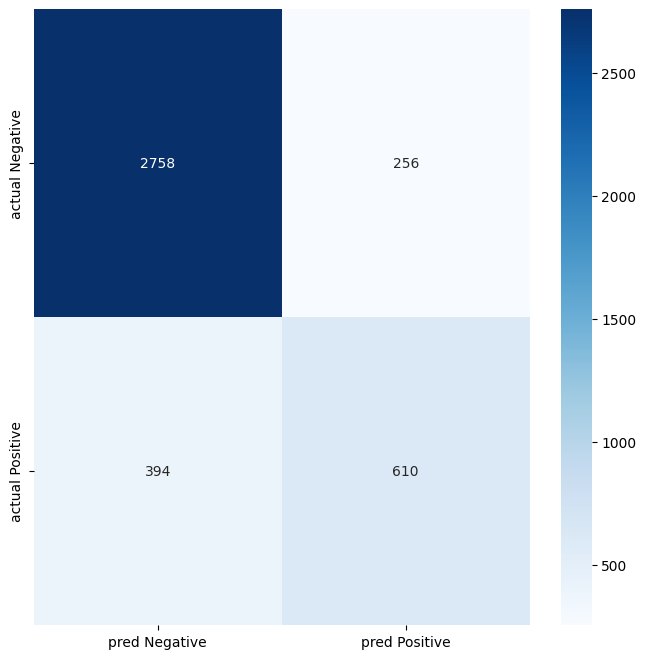

In [38]:
# 혼동 행렬 그래프 시각화
plt.figure(figsize = (8,8))

sns.heatmap(
    cm, annot = True, cmap = 'Blues', fmt = 'd',
    xticklabels = ['pred Negative', 'pred Positive'],
    yticklabels = ['actual Negative', 'actual Positive']
)
plt.show()

In [39]:
print('정확도 : ', round(acc,2))
print('정밀도 : ', round(prc,2))
print('재현율 : ',round(rcll,2))
print('f1 : ', round(f1, 2))

정확도 :  0.84
정밀도 :  0.7
재현율 :  0.61
f1 :  0.65


In [40]:
# 데이터의 불균형을 해결 해보자
# 샘플링 기법을 이용하여 데이터의 균형을 맞춘다.
# 모델 생성 시 불균형한 데이터들에 가중치를 특별 부여
logR2 = LogisticRegression(class_weight = 'balanced')

In [41]:
logR2.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [42]:
pred_2 = logR2.predict(X_test)

In [47]:
acc2 = accuracy_score(y_test, pred_2)
prc2 = precision_score(y_test, pred_2)
rcll2 = recall_score(y_test, pred_2)
f1_2 = f1_score(y_test, pred_2)

In [48]:
print('정확도 : ', round(acc, 2), round(acc2, 2))
print('정밀도 : ', round(prc, 2), round(prc2, 2))
print('재현율 : ', round(rcll, 2), round(rcll2, 2))
print('f1 : ', round(f1, 2), round(f1_2, 2))

정확도 :  0.84 0.82
정밀도 :  0.7 0.59
재현율 :  0.61 0.85
f1 :  0.65 0.7


In [50]:
# 극단치의 데이터들을 수정
# 극단치를 제거
from outlier import outlier_iqr

In [55]:
outlier_drop_df, outlier_dict = outlier_iqr(df, *df.drop('class_1',axis=1).columns,drop=True)


                지정된 컬럼의 이름 : age,
                상단의 경계 값: 82.5,
                하단의 경계값 : -9.5
            
 상단의 경계를 벗어나는 데이터 개수 : 0 하단의 경계를 벗어나는 데이터 개수 : 0

                지정된 컬럼의 이름 : height_cm,
                상단의 경계 값: 193.40000000000003,
                하단의 경계값 : 143.8
            
 상단의 경계를 벗어나는 데이터 개수 : 1 하단의 경계를 벗어나는 데이터 개수 : 9

                지정된 컬럼의 이름 : weight_kg,
                상단의 경계 값: 100.94999999999999,
                하단의 경계값 : 32.55000000000001
            
 상단의 경계를 벗어나는 데이터 개수 : 81 하단의 경계를 벗어나는 데이터 개수 : 2

                지정된 컬럼의 이름 : body fat_%,
                상단의 경계 값: 42.75,
                하단의 경계값 : 3.150000000000002
            
 상단의 경계를 벗어나는 데이터 개수 : 80 하단의 경계를 벗어나는 데이터 개수 : 2

                지정된 컬럼의 이름 : diastolic,
                상단의 경계 값: 108.5,
                하단의 경계값 : 48.5
            
 상단의 경계를 벗어나는 데이터 개수 : 17 하단의 경계를 벗어나는 데이터 개수 : 37

                지정된 컬럼의 이름 : systolic,
                상단의 경계 값: 172.5,
                하단의 경계값 : 88.5
          

In [56]:
len(body)

13393

In [57]:
len(outlier_drop_df)

12634

In [58]:
outlier_drop_df['class_1'].value_counts()

class_1
0    9316
1    3318
Name: count, dtype: int64

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    outlier_drop_df.drop(['class','class_1'],axis=1),
    outlier_drop_df['class_1'],
    test_size=0.3,
    stratify=outlier_drop_df['class_1']
)

In [64]:
logR2.fit(X_train, y_train)

pred_3 = logR2.predict(X_test)

acc_3 = accuracy_score(y_test, pred_3)
prc_3 = precision_score(y_test, pred_3)
rcll_3 = recall_score(y_test, pred_3)
f1_3 = f1_score(y_test, pred_3)


In [65]:
print('정확도 : ', round(acc_3, 2))
print('정밀도 : ', round(prc_3, 2))
print('재현율 : ', round( rcll_3, 2))
print('f1 : ', round(f1_3, 2))

정확도 :  0.82
정밀도 :  0.62
재현율 :  0.85
f1 :  0.72


In [66]:
# 데이터 불균형 문제를 해결하기 위해 샘플링 기법 -> class_weight는 제외

# 언더 샘플링, SMOTE 사용
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [67]:
# fit_resample() -> 독립 변수, 종속 변수 대입
undersample = RandomUnderSampler(sampling_strategy=1)
x = df.drop(['class', 'class_1'], axis = 1)
y = df['class_1']

x_under, y_under = undersample.fit_resample(x, y)

In [68]:
len(x_under)

6696

In [78]:
def logR_function(x, y, weight = None):
    # x : 독립변수
    # y : 종속변수
    # weight : class_weight의 인자 값
    X_train, X_test, y_train, y_test = train_test_split(
        x, y, test_size = 0.3, random_state=42, stratify=y
    )

    # 모델 생성
    model = LogisticRegression(class_weight = weight)

    # 학습
    model.fit(X_train, y_train)

    # 예측
    pred = model.predict(X_test)

    # 성능지표
    acc = accuracy_score(y_test, pred)
    prc = precision_score(y_test, pred, average ='macro')
    rcll = recall_score(y_test, pred, average = 'macro')
    f1 = f1_score(y_test, pred, average = 'macro')

    print('정확도 : ', round(acc, 2))
    print('정밀도 : ', round(prc, 2))
    print('재현율 : ', round(rcll, 2))
    print('f1 : ', round(f1, 2))
    return pred

In [74]:
under_pred = logR_function(x_under, y_under)

정확도 :  0.84
정밀도 :  0.81
재현율 :  0.87
f1 :  0.84


In [75]:
smote = SMOTE(sampling_strategy=1)

x_over, y_over = smote.fit_resample(x, y)

len(x_over)

20090

In [76]:
over_pred = logR_function(x_over, y_over)

정확도 :  0.85
정밀도 :  0.83
재현율 :  0.88
f1 :  0.86


In [77]:
body

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B
...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,M,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C
13389,21.0,M,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D
13390,39.0,M,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A
13391,64.0,F,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D


### 연습문제
- body 데이터에서 성별 컬럼을 0, 1로 변환
- class 컬럼의 데이터들은 A는 1, B는 2, C는 3, D는 4로 변경
- 극단치데이터를 경계 값들로 대체
- 로지스틱 회귀를 이용하여 혼동행렬, 나머지 성능 지표를 확인

In [80]:
body['gender'] = body['gender'].map(
    {
        'M' : 0,
        'F' : 1
    }
)

In [81]:
body['class'].map(
    lambda x : 1 if x == 'A' else 2 if x == 'B' else 3 if x == 'C' else 4
)

0        3
1        1
2        3
3        2
4        2
        ..
13388    3
13389    4
13390    1
13391    4
13392    3
Name: class, Length: 13393, dtype: int64

In [83]:
body['class'] = body['class'].map(
    {
        'A' : 1,
        'B' : 2,
        'C' : 3,
        'D' : 4
    }
)

In [84]:
cols = body.drop('class', axis = 1).columns

outlier_df, whis_dict = outlier_iqr(body, *cols)


                지정된 컬럼의 이름 : age,
                상단의 경계 값: 82.5,
                하단의 경계값 : -9.5
            
 상단의 경계를 벗어나는 데이터 개수 : 0 하단의 경계를 벗어나는 데이터 개수 : 0

                지정된 컬럼의 이름 : gender,
                상단의 경계 값: 2.5,
                하단의 경계값 : -1.5
            
 상단의 경계를 벗어나는 데이터 개수 : 0 하단의 경계를 벗어나는 데이터 개수 : 0

                지정된 컬럼의 이름 : height_cm,
                상단의 경계 값: 193.40000000000003,
                하단의 경계값 : 143.8
            
 상단의 경계를 벗어나는 데이터 개수 : 1 하단의 경계를 벗어나는 데이터 개수 : 9

                지정된 컬럼의 이름 : weight_kg,
                상단의 경계 값: 100.94999999999999,
                하단의 경계값 : 32.55000000000001
            
 상단의 경계를 벗어나는 데이터 개수 : 81 하단의 경계를 벗어나는 데이터 개수 : 2

                지정된 컬럼의 이름 : body fat_%,
                상단의 경계 값: 43.0,
                하단의 경계값 : 3.0
            
 상단의 경계를 벗어나는 데이터 개수 : 77 하단의 경계를 벗어나는 데이터 개수 : 0

                지정된 컬럼의 이름 : diastolic,
                상단의 경계 값: 108.5,
                하단의 경계값 : 48.5
            
 상단의 경계를 벗어나는 데이터 

In [85]:
outlier_df.shape

(13393, 12)

In [87]:
outlier_df['class'].value_counts()

class
3    3349
4    3349
1    3348
2    3347
Name: count, dtype: int64

In [90]:
x = outlier_df.drop('class', axis = 1)
y = outlier_df['class']

pred = logR_function(x, y)

정확도 :  0.6
정밀도 :  0.6
재현율 :  0.6
f1 :  0.6


- 정밀도, 재현율, f1_score에서는 다중 분류 모델에서는 일반적인 계산 x (error 발생)
    - average
        - 'macro'
            - 다중 분류에서 각각의 점수들이 생성이 되면 점수들의 평균을 출력
            - a : 90점, b : 30점, c: 50점, d : 10점
            - 점수들의 평균 : 45점
            - 모든 클래스의 점수를 차별없이 똑같이 잘 맞추는 모델
        - 'weighted'
            - 각 클래스별 가중치(비율)를 생성하여 계산
            - a : 100/150 90점, b : 30 / 150 30점, c : 20 / 150 20점
            - (90 * 100/150) + (30 * 30/150) + (20 * 20/150)
        - 'micro'
            - 혼동행렬의 모든 값들은 합산에서 점수를 생성
            - 이진 분류에서 정확도 똑같은 값들이 생성

In [91]:
datas = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

In [92]:
datas

[        age  gender  height_cm  weight_kg  body fat_%  diastolic  systolic  \
 1251   56.0     1.0      152.4       50.5        31.1       89.0     158.0   
 5868   26.0     0.0      166.0       70.6        29.1       82.0     122.0   
 11112  60.0     1.0      161.2       61.6        37.5       93.0     149.0   
 1210   33.0     0.0      174.2       72.8        13.2       83.0     124.0   
 4208   29.0     0.0      176.4       66.2        20.4       64.0     117.0   
 ...     ...     ...        ...        ...         ...        ...       ...   
 11227  58.0     0.0      164.3       86.0        33.6       94.0     151.0   
 13232  23.0     1.0      155.5       55.0        26.2       66.0     103.0   
 7654   25.0     0.0      172.6       63.9        16.4       82.0     135.0   
 12582  23.0     0.0      173.7       78.5        12.7       87.0     143.0   
 13020  30.0     0.0      180.0       83.6        13.4       99.0     145.0   
 
        gripForce  sit and bend forward_cm  sit-up

In [93]:
datas[3]

11398    3
11041    2
5262     2
3386     1
9410     2
        ..
3902     4
11139    4
8182     1
13       3
10       1
Name: class, Length: 4018, dtype: int64

In [94]:
cm = confusion_matrix(datas[3], pred)

In [95]:
cm

array([[739, 239,  26,   0],
       [266, 415, 284,  39],
       [120, 192, 492, 201],
       [ 27,  45, 162, 771]], dtype=int64)

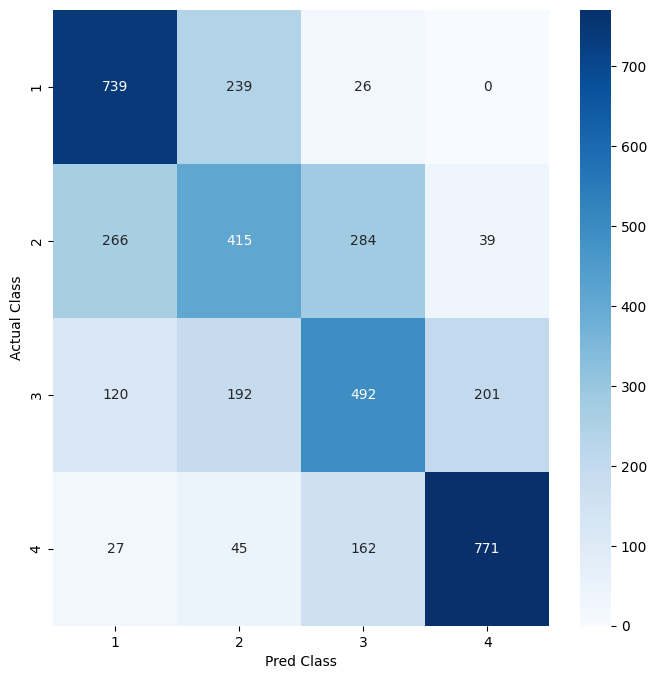

In [98]:
plt.figure(figsize = (8, 8))

sns.heatmap(
    cm,
    annot = True,
    cmap = 'Blues',
    fmt = 'd',
    xticklabels=[1,2,3,4],
    yticklabels=[1,2,3,4]
)
plt.ylabel('Actual Class')
plt.xlabel('Pred Class')
plt.show()